# Flood Probability Prediction with Regression

This project uses regression models to predict `FloodProbability` based on environmental, infrastructure, planning, and socio-economic factors.

The project includes data exploration, correlation analysis, feature and target preparation, train-validation splitting, regression modelling, and model evaluation using R², RMSE, and MAE.

Linear Regression and HistGradientBoosting Regressor are compared to determine which model performs better. The selected final model is then trained on the complete training dataset and used to predict the unknown `FloodProbability` values in the test dataset.




<a href="https://www.kaggle.com/competitions/playground-series-s4e5" target="_blank">
Click here for the dataset
</a>

**Data Dictionary**

| Feature | Description |
|---|---|
| `id` | Unique identifier |
| `MonsoonIntensity` | Intensity of monsoon conditions |
| `TopographyDrainage` | Drainage characteristics of the area |
| `RiverManagement` | River management conditions |
| `Deforestation` | Level of deforestation |
| `Urbanization` | Level of urban development |
| `ClimateChange` | Climate change related factor |
| `DamsQuality` | Quality of dam infrastructure |
| `Siltation` | Level of sediment accumulation |
| `AgriculturalPractices` | Agricultural practices factor |
| `Encroachments` | Encroachment on natural areas |
| `IneffectiveDisasterPreparedness` | Disaster preparedness related factor |
| `DrainageSystems` | Drainage system conditions |
| `CoastalVulnerability` | Vulnerability of coastal areas |
| `Landslides` | Landslide related factor |
| `Watersheds` | Watershed conditions |
| `DeterioratingInfrastructure` | Infrastructure deterioration |
| `PopulationScore` | Population related score |
| `WetlandLoss` | Level of wetland loss |
| `InadequatePlanning` | Planning related factor |
| `PoliticalFactors` | Political factor score |
| `FloodProbability` | Target variable representing flood probability |

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

**Load Data**

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [3]:
train.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,4,2,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,6,9,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,5,6,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,8,5,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,3,5,2,2,6,6,4,1,2,3,5,0.415


In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (1117957, 22)
Test shape: (745305, 21)
Sample submission shape: (745305, 2)


**Exploratory Data Analysis**

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null  int64  
 1

In [6]:
train.isnull().sum()

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

In [7]:
print("Duplicated rows:", train.duplicated().sum())

Duplicated rows: 0


In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1117957.0,558978.000000,322726.531782,0.000,279489.00,558978.000,838467.00,1117956.000
MonsoonIntensity,1117957.0,4.921450,2.056387,0.000,3.00,5.000,6.00,16.000
TopographyDrainage,1117957.0,4.926671,2.093879,0.000,3.00,5.000,6.00,18.000
RiverManagement,1117957.0,4.955322,2.072186,0.000,4.00,5.000,6.00,16.000
Deforestation,1117957.0,4.942240,2.051689,0.000,4.00,5.000,6.00,17.000
Urbanization,1117957.0,4.942517,2.083391,0.000,3.00,5.000,6.00,17.000
ClimateChange,1117957.0,4.934093,2.057742,0.000,3.00,5.000,6.00,17.000
DamsQuality,1117957.0,4.955878,2.083063,0.000,4.00,5.000,6.00,16.000
Siltation,1117957.0,4.927791,2.065992,0.000,3.00,5.000,6.00,16.000
AgriculturalPractices,1117957.0,4.942619,2.068545,0.000,3.00,5.000,6.00,16.000


**Target Distribution**

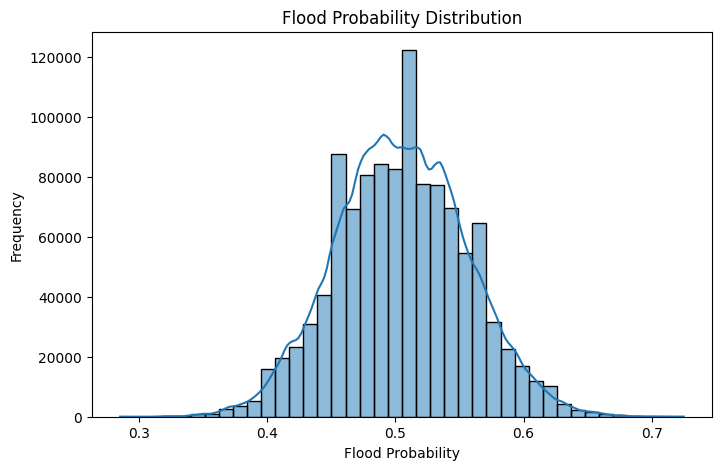

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    train["FloodProbability"],
    bins=40,
    kde=True
)

plt.title("Flood Probability Distribution")
plt.xlabel("Flood Probability")
plt.ylabel("Frequency")

plt.show()

In [11]:
train.corr(numeric_only=True)

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,IneffectiveDisasterPreparedness,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
id,1.000000,-0.000093,-0.001518,-0.000413,-0.000080,0.000580,-0.000188,0.000133,0.000281,-0.000103,-0.000147,-0.000208,0.000558,-0.001386,0.001078,0.000215,-0.000385,0.000625,0.000931,-0.001535,-0.000155,-0.000184
MonsoonIntensity,-0.000093,1.000000,-0.007362,-0.008070,-0.007251,-0.009309,-0.008031,-0.007787,-0.007836,-0.008232,-0.010309,-0.008032,-0.009716,-0.010659,-0.009121,-0.008900,-0.008486,-0.008679,-0.006811,-0.008155,-0.008474,0.189098
TopographyDrainage,-0.001518,-0.007362,1.000000,-0.009924,-0.008548,-0.010532,-0.009619,-0.007607,-0.009824,-0.009496,-0.012887,-0.010746,-0.010056,-0.012526,-0.010240,-0.011067,-0.006628,-0.010815,-0.010267,-0.011617,-0.012350,0.187635
RiverManagement,-0.000413,-0.008070,-0.009924,1.000000,-0.008574,-0.012292,-0.009237,-0.008711,-0.010058,-0.010783,-0.011615,-0.010675,-0.011277,-0.011680,-0.008994,-0.011412,-0.005827,-0.006727,-0.010069,-0.009673,-0.011550,0.187131
Deforestation,-0.000080,-0.007251,-0.008548,-0.008574,1.000000,-0.012248,-0.008266,-0.009356,-0.011536,-0.010039,-0.013175,-0.009512,-0.010490,-0.012388,-0.009257,-0.010671,-0.008862,-0.011777,-0.011004,-0.010424,-0.009661,0.184001
Urbanization,0.000580,-0.009309,-0.010532,-0.012292,-0.012248,1.000000,-0.011199,-0.011128,-0.010153,-0.010559,-0.010784,-0.012685,-0.012572,-0.014497,-0.010582,-0.012107,-0.010656,-0.011485,-0.011023,-0.011584,-0.013005,0.180861
ClimateChange,-0.000188,-0.008031,-0.009619,-0.009237,-0.008266,-0.011199,1.000000,-0.008427,-0.009457,-0.011517,-0.012533,-0.011346,-0.009650,-0.013005,-0.009352,-0.009882,-0.006324,-0.010332,-0.009376,-0.010772,-0.011379,0.184761
DamsQuality,0.000133,-0.007787,-0.007607,-0.008711,-0.009356,-0.011128,-0.008427,1.000000,-0.009401,-0.009033,-0.010890,-0.009515,-0.010439,-0.012096,-0.009924,-0.009085,-0.009831,-0.009599,-0.009372,-0.011374,-0.013081,0.187996
Siltation,0.000281,-0.007836,-0.009824,-0.010058,-0.011536,-0.010153,-0.009457,-0.009401,1.000000,-0.010179,-0.010628,-0.009099,-0.010702,-0.011762,-0.009173,-0.009457,-0.006312,-0.008739,-0.008667,-0.009079,-0.008493,0.186789
AgriculturalPractices,-0.000103,-0.008232,-0.009496,-0.010783,-0.010039,-0.010559,-0.011517,-0.009033,-0.010179,1.000000,-0.012244,-0.010763,-0.010845,-0.011415,-0.010624,-0.009901,-0.008708,-0.008958,-0.011392,-0.010418,-0.011157,0.183366


In [12]:
train.corr(numeric_only=True)["FloodProbability"].sort_values(ascending=False)

FloodProbability                   1.000000
DeterioratingInfrastructure        0.190007
MonsoonIntensity                   0.189098
DamsQuality                        0.187996
TopographyDrainage                 0.187635
RiverManagement                    0.187131
Siltation                          0.186789
PopulationScore                    0.185890
Landslides                         0.185346
ClimateChange                      0.184761
Deforestation                      0.184001
WetlandLoss                        0.183396
AgriculturalPractices              0.183366
IneffectiveDisasterPreparedness    0.183109
PoliticalFactors                   0.182417
Watersheds                         0.181907
InadequatePlanning                 0.180968
Urbanization                       0.180861
DrainageSystems                    0.179305
Encroachments                      0.178841
CoastalVulnerability               0.177774
id                                -0.000184
Name: FloodProbability, dtype: f

**Prepare Features and Target**

The identifier column `id` is excluded from modelling because it does not represent a predictive feature.

`FloodProbability` is used as the numerical target variable.

In [13]:
x = train.drop(["id", "FloodProbability"], axis=1)
y = train["FloodProbability"]

*Train / Validation Split*

In [14]:
x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)

Training data: (894365, 20)
Validation data: (223592, 20)


**Model Evaluation**

The models are evaluated using:

- **R²** — measures how much of the variation in the target is explained by the model.
- **RMSE** — penalizes larger prediction errors more strongly.
- **MAE** — represents the average absolute prediction error.

**Modelling**

*Linear Regression*

Linear Regression is used as a simple and interpretable regression model.

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

pred = lr.predict(x_val)

In [20]:
print("R²:", r2_score(y_val, pred))
print("RMSE:", mean_squared_error(y_val, pred) ** 0.5)
print("MAE:", mean_absolute_error(y_val, pred))

R²: 0.8448773362840328
RMSE: 0.0200800046586289
MAE: 0.01579247136376025


*HistGradientBoosting Regressor*

A nonlinear gradient boosting model is also tested to compare its performance with Linear Regression.

In [21]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(random_state=42)

hgb.fit(x_train, y_train)

pred_hgb = hgb.predict(x_val)

In [22]:
print("R²:", r2_score(y_val, pred_hgb))
print("RMSE:", mean_squared_error(y_val, pred_hgb) ** 0.5)
print("MAE:", mean_absolute_error(y_val, pred_hgb))

R²: 0.765435446907509
RMSE: 0.024692062860352266
MAE: 0.0201618496314451


**Model Comparison**

In [23]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "HistGradientBoosting"],
    "R²": [
        r2_score(y_val, pred),
        r2_score(y_val, pred_hgb)
    ],
    "RMSE": [
        mean_squared_error(y_val, pred) ** 0.5,
        mean_squared_error(y_val, pred_hgb) ** 0.5
    ],
    "MAE": [
        mean_absolute_error(y_val, pred),
        mean_absolute_error(y_val, pred_hgb)
    ]
})

results

,Model,R²,RMSE,MAE
0,Linear Regression,0.844877,0.020080,0.015792
1,HistGradientBoosting,0.765435,0.024692,0.020162


**Actual vs Predicted**

In [24]:
residuals = y_val - pred

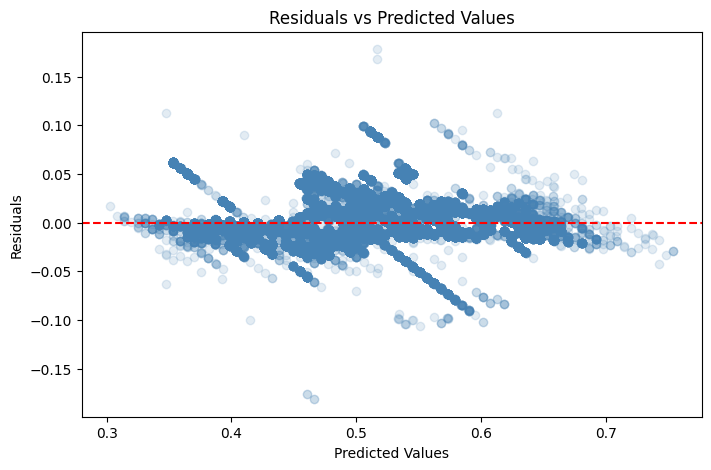

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(pred, residuals, color="steelblue", alpha=0.15, marker="o")
plt.axhline(0, linestyle="--", color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

*Feature Coefficients*

In [35]:
coefs = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": lr.coef_
})

coefs.sort_values("Coefficient", ascending=False).head(10)

,Feature,Coefficient
16,PopulationScore,0.005681
3,Deforestation,0.005681
12,CoastalVulnerability,0.005671
2,RiverManagement,0.005662
4,Urbanization,0.005659
5,ClimateChange,0.005659
6,DamsQuality,0.005653
14,Watersheds,0.005648
9,Encroachments,0.005646
19,PoliticalFactors,0.005646


**Final Modelling**

In [28]:
final_model = LinearRegression()

final_model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[0.01,0.01,0.01,...,0.01,0.01,0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](20,)","['MonsoonIntensity','TopographyDrainage','RiverManagement',..., 'WetlandLoss','InadequatePlanning','PoliticalFactors']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.0533
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [29]:
x_test = test.drop("id", axis=1)

In [30]:
test_pred = final_model.predict(x_test)

In [31]:
submission = sample_submission.copy()

submission["FloodProbability"] = test_pred

submission.head()

,id,FloodProbability
0,1117957,0.573615
1,1117958,0.455243
2,1117959,0.454742
3,1117960,0.466204
4,1117961,0.466068


In [32]:
submission.to_csv("submission.csv", index=False)

**Summary**

This project predicted `FloodProbability` using environmental, infrastructure, planning, and socio-economic features.

After exploring the data, the features and target were prepared and the dataset was divided into training and validation sets.

Linear Regression and HistGradientBoosting Regressor were compared using R², RMSE, and MAE. Linear Regression performed better, achieving an R² of approximately 0.845, an RMSE of 0.0201, and an MAE of 0.0158.

The selected model was then trained on the complete training data and used to estimate the unknown `FloodProbability` values in the test dataset.

Higher predicted values indicate a relatively higher flood probability, while lower values indicate a relatively lower probability.

Overall, the project shows how regression can be used to predict continuous values for new observations.